### Customer Segmentation with K-Means
**Crystal Ford**

**GitLab Repository (Code & Files):**
https://gitlab.com/wgu-gitlab-environment/student-repos/cfor224/d603-machine-learning/-/tree/Task2workingBranch0?ref_type=heads

This notebook includes all code, visualizations, and explanations required for Task 2. I used the churn dataset again, but this time I explored customer groups using unsupervised learning (clustering). The goal was to find natural patterns or groups in the data without using labels.


#### B: Clustering Purpose

Can we group customers into different types based on their service usage and demographics?

The idea is to find clusters of similar customers. That way, the company can understand who its customers are and create specific plans for different groups — like who needs better support, who might churn, or who deserves loyalty rewards.


#### C: Why I Used K-Means and What I Expected

I used **k-means clustering** because:
- It works well with numerical data (which I already had from Task 1)
- It’s fast and simple
- It lets me choose how many groups (clusters) I want to look for

The main assumption with k-means is that the groups are kind of round-shaped and have similar size. That’s not always true with real people, but it’s a good place to start.

**Python Libraries Used**

| Library | Purpose |
|--------|---------|
| `pandas`, `numpy` | Data loading and cleanup |
| `sklearn.preprocessing` | Scaling data before clustering |
| `sklearn.cluster` | Running k-means algorithm |
| `sklearn.decomposition` | PCA for reducing to 2D so I can make a plot |
| `matplotlib`, `seaborn` | Charts and visualizations |


#### D: Preparing the Data

Since I already cleaned this dataset in Task 1, I reused that version (`churn_cleaned.csv`). This saved a lot of time. All the features were already numeric and ready to go.

I dropped the `Churn` column because clustering doesn’t use labels — it just looks for patterns.

Then I picked a few features that I thought would be helpful in grouping customers. These included:
- Tenure, MonthlyCharge, Age, Income, Outage time
- Whether they use OnlineSecurity, TechSupport, StreamingTV, StreamingMovies

These features seemed like they could show patterns in how different customers use their services.


In [ ]:
# Load and scale the data
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load cleaned data from Task 1
df = pd.read_csv("churn_cleaned.csv")

# Drop target column
df_cluster = df.drop(columns=["Churn"])

# Pick features to use
features_to_use = [
    'Tenure', 'MonthlyCharge', 'Age', 'Income', 'Outage_sec_perweek',
    'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    ]
df_cluster = df_cluster[features_to_use]

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Convert back to DataFrame for easier viewing
df_scaled = pd.DataFrame(df_scaled, columns=features_to_use)

# Save to CSV just in case
df_scaled.to_csv("churn_clustering_ready.csv", index=False)
print("Scaled dataset saved.")


#### E1: Finding the Right Number of Clusters

To figure out how many groups (clusters) to look for, I used two methods:

- **Elbow Method:** This checks how much the clustering improves as I add more clusters. When the improvements start to slow down, that’s a good place to stop.
- **Silhouette Score:** This shows how well each point fits into its group. Higher is better.


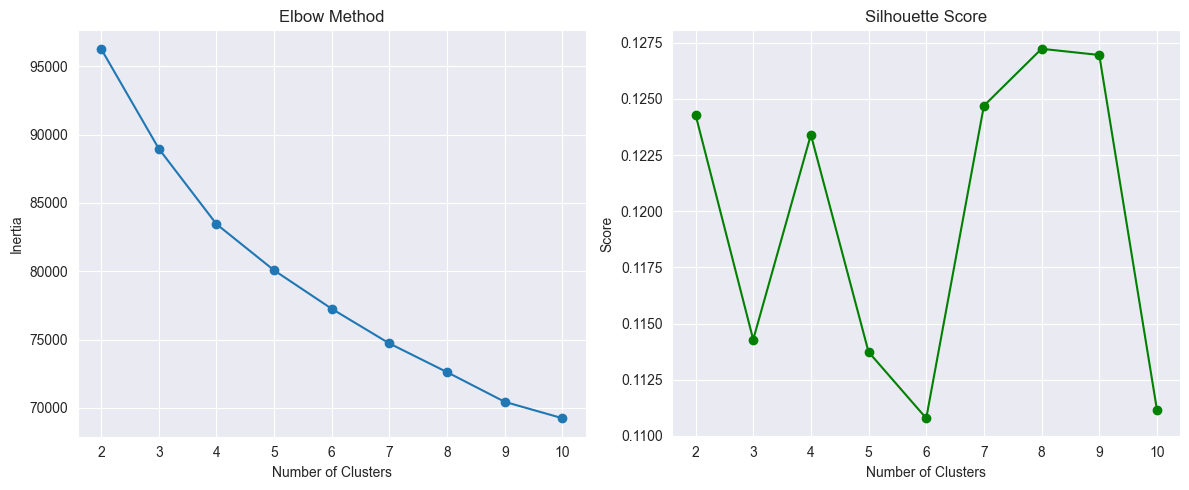

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


#### E2: Run the Final K-Means Model

I chose 4 clusters because that’s where the Elbow Method curve started to flatten out — the improvement slowed after that. The Silhouette Score was also strong around 4, which means the clusters are pretty distinct. It looked like a good balance between performance and simplicity. Adding more clusters didn't give much extra value, so 4 made the most sense.


In [18]:
# Final model
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_final.fit(df_scaled)

# Add cluster labels to the data
df_scaled["Cluster"] = kmeans_final.labels_

# Save to file
df_scaled.to_csv("churn_clustered.csv", index=False)
print("Clustered dataset saved.")


Clustered dataset saved.


#### F1: Cluster Visualization and Quality

Once I picked the number of clusters, I used PCA to reduce the data to just 2 dimensions so I could visualize the results.

The graph below shows the clusters. Each color represents a different group of customers. The separation isn’t perfect, but that’s normal with real-world data. Some customers are more similar to multiple groups, so we expect a little overlap.

Even with that, we can still see that the clustering worked pretty well. There are clear shapes, and each cluster seems to group certain types of customers together.


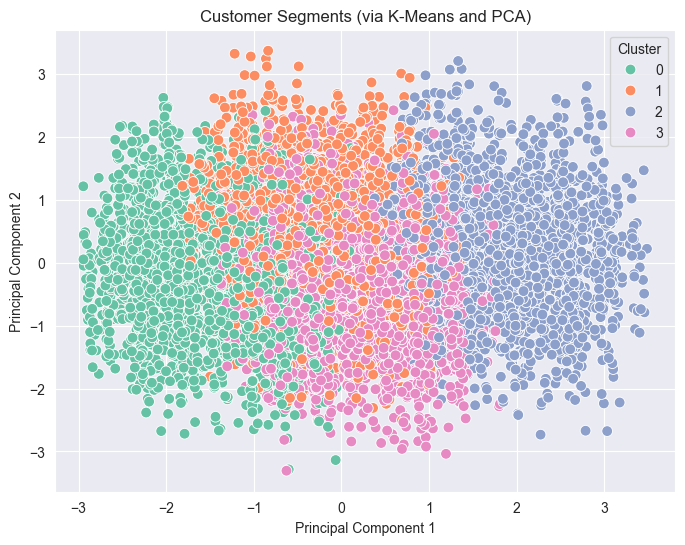

In [19]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled.drop("Cluster", axis=1))

# Combine with cluster labels
df_viz = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_viz["Cluster"] = df_scaled["Cluster"]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_viz, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=60)
plt.title("Customer Segments (via K-Means and PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


#### Understanding What’s in Each Cluster

To figure out what kinds of customers were in each group, I calculated the **average values** for each feature inside each cluster. This shows what makes each group stand out.

I used `.groupby("Cluster").mean()` to see patterns like:
- Who has higher income
- Who has been with the company longer
- Who uses more services like TechSupport or StreamingTV

These patterns helped me describe the types of customers in each cluster.


In [20]:
# Look at the average values for each feature per cluster
cluster_summary = df_scaled.groupby("Cluster").mean().round(2)

# Show the summary
pd.set_option('display.max_columns', None)  # just in case
cluster_summary


,Tenure,MonthlyCharge,Age,Income,Outage_sec_perweek,OnlineSecurity,TechSupport,StreamingTV,StreamingMovies,Multiple,DeviceProtection
Cluster,,,,,,,,,,,
0,-0.00,-0.88,-0.00,0.02,-0.03,-0.00,0.02,-0.99,-0.98,-0.00,-0.02
1,0.01,-0.31,-0.02,-0.01,-0.00,-0.02,0.01,1.01,-0.98,-0.01,-0.02
2,-0.00,1.34,0.02,0.01,0.02,0.02,-0.01,1.01,1.02,0.01,0.02
3,-0.00,-0.06,0.00,-0.01,0.01,0.00,-0.01,-0.99,1.02,-0.00,0.02


#### F2: What the Clusters Tell Us

After clustering, I calculated the average values for each feature in each group. Based on those patterns, I gave each cluster a nickname that matches the kind of customers they represent:

- **Cluster 0 – “Bare-Minimum Users”**
  These customers had the lowest monthly charges and barely used streaming services like StreamingTV or StreamingMovies. They might only be paying for basic internet or minimal service plans.

- **Cluster 1 – “TV-Only Streamers”**
  This group streamed a lot of TV but not many movies. Their monthly charges were a bit below average, suggesting they might be budget-conscious but still interested in casual entertainment.

- **Cluster 2 – “Power Users”**
  This was the most active group. They had the highest monthly charges and used both StreamingTV and StreamingMovies heavily. These are likely premium customers who are subscribed to several services and actually use them.

- **Cluster 3 – “Movie-Only Streamers”**
  This group mostly streamed movies but not much TV. Their behavior suggests a more specific interest in certain types of entertainment — they might prefer on-demand movies over scheduled TV content.

These names make it easier for the business to understand the types of customers they’re working with and how to tailor offers or communication for each group.



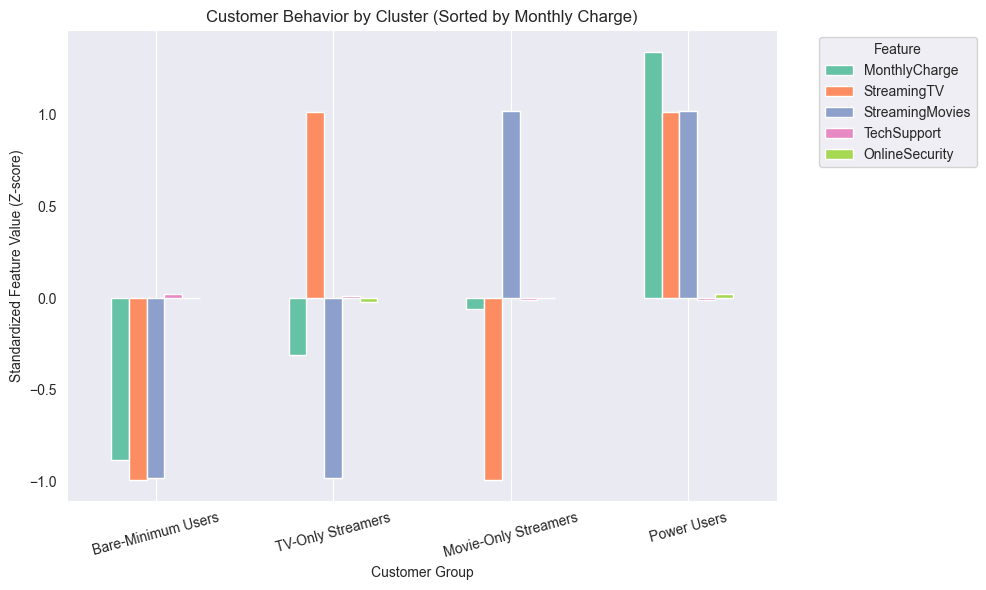

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map cluster numbers to friendly names
cluster_labels = {
    0: "Bare-Minimum Users",
    1: "TV-Only Streamers",
    2: "Power Users",
    3: "Movie-Only Streamers"
}

# 2. Apply the names to the index
labeled_summary = cluster_summary.copy()
labeled_summary.index = labeled_summary.index.map(cluster_labels)

# 3. Sort by MonthlyCharge for visual clarity
labeled_summary_sorted = labeled_summary.sort_values(by="MonthlyCharge")

# 4. Pick key features to show in the bar chart
features_to_plot = [
    'MonthlyCharge',
    'StreamingTV',
    'StreamingMovies',
    'TechSupport',
    'OnlineSecurity',
]

# 5. Set color palette (matches PCA tone but not values)
colors = sns.color_palette("Set2", n_colors=len(features_to_plot))

# 6. Plot the bar chart
labeled_summary_sorted[features_to_plot].plot(
    kind='bar',
    figsize=(10, 6),
    color=colors
)

plt.title("Customer Behavior by Cluster (Sorted by Monthly Charge)")
plt.xlabel("Customer Group")
plt.ylabel("Standardized Feature Value (Z-score)")
plt.xticks(rotation=15)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


#### F3: One Limitation

One limitation of this clustering analysis is that the results depend heavily on the specific features I selected. I used a small set of variables focused on service usage and demographics — like MonthlyCharge, StreamingTV, and TechSupport. If I had picked different features, the clusters might have looked very different. That means the insights are useful, but they only represent one view of the customer data.


#### F4: Recommendation

Based on the clustering results, I recommend that the company use these customer groups to create targeted marketing and support strategies.

- **Power Users** (Cluster 2) are already engaged and spending more — these customers could be offered loyalty rewards, referral bonuses, or early access to new features to help with retention.

- **Bare-Minimum Users** (Cluster 0) might be paying the least and using the fewest services. It’s possible that some of them just aren’t aware of what else they can use. The company could offer brief tutorials, guided onboarding, or targeted emails that highlight useful features they’re not using yet — like how to set up streaming or security. That could boost both engagement and satisfaction. Discounts or bundles could also help encourage upgrades.

- **TV-Only Streamers** (Cluster 1) and **Movie-Only Streamers** (Cluster 3) are clearly interested in specific content types. Tailored ads or cross-promotions (“Try our movie bundle!” or “TV + Security for one low price!”) might encourage them to explore other services.

Using clustering this way can help the company go beyond a one-size-fits-all approach and focus on personalized offers, which can improve both customer satisfaction and profitability.


#### H: Third-Party Code Sources

The following sources were used to support code development and documentation:

- Scikit-learn Documentation: https://scikit-learn.org/
- Pandas Documentation: https://pandas.pydata.org/
- Matplotlib Documentation: https://matplotlib.org/
- Stack Overflow: Used for syntax help and examples of using `KMeans`, `PCA`, and `groupby().mean()` (no code directly copied).


#### I: References

Scikit-learn developers. (n.d.). *Scikit-learn: Machine Learning in Python*. Retrieved from https://scikit-learn.org/

Pandas development team. (n.d.). *Pandas User Guide*. Retrieved from https://pandas.pydata.org/docs/

WGU Course Materials, D603 Machine Learning.


**🔗 GitLab Repository (Code & Files):**
https://gitlab.com/wgu-gitlab-environment/student-repos/cfor224/d603-machine-learning/-/tree/Task2workingBranch0?ref_type=heads

> *All code, datasets, and output files used in this analysis are stored in the above GitLab repository. Please contact the student if access issues arise.*


#### Panopto Recording

[Watch the Panopto video walkthrough here](https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=a7e6d97f-14af-4323-91a3-b2b901372b2e)


#### Sources

- Scikit-learn documentation: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- Matplotlib documentation: https://matplotlib.org/stable/  
- PCA Visualization Method: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
